In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import f1_score, ConfusionMatrixDisplay
import cv2
import pandas as pd
import pickle
import os

In [2]:
# Initialize empty lists to hold all data and labels
all_data = []
all_labels = []

def file_open(file_path):
    try:
        with open(file_path, 'rb') as f:
            data_dict = pickle.load(f, encoding='latin1')
            all_data.append(data_dict['data'])  # Append batch data
            all_labels.extend(data_dict['labels'])  # Extend labels
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")

# Load all batches
base_path = r'.\Dataset\cifar-10-batches-py'
for i in range(1, 6):
    file_path = os.path.join(base_path, f"data_batch_{i}")
    file_open(file_path)

# Convert the list of arrays into a single numpy array
all_data = np.vstack(all_data)  # Stack all data arrays vertically
all_labels = np.array(all_labels)  # Convert labels to numpy array

print(f"Data shape: {all_data.shape}")  # Should be (50000, 3072)
print(f"Labels shape: {all_labels.shape}")  # Should be (50000,)


Data shape: (50000, 3072)
Labels shape: (50000,)


In [3]:
all_data[1]

array([154, 126, 105, ..., 139, 142, 144], dtype=uint8)

In [4]:
img_3d = all_data[0].reshape((3, 32, 32))
img = img_3d.transpose(1, 2, 0)

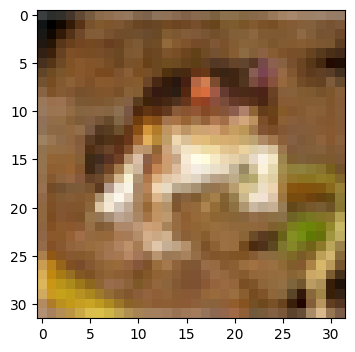

In [5]:
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.show()

In [6]:
all_data.shape

(50000, 3072)

In [7]:
all_data

array([[ 59,  43,  50, ..., 140,  84,  72],
       [154, 126, 105, ..., 139, 142, 144],
       [255, 253, 253, ...,  83,  83,  84],
       ...,
       [ 35,  40,  42, ...,  77,  66,  50],
       [189, 186, 185, ..., 169, 171, 171],
       [229, 236, 234, ..., 173, 162, 161]], dtype=uint8)

In [8]:
data = pd.DataFrame({
    'image_data': list(all_data),  # Each row will contain 3072 values for image data
    'label': all_labels  # Fine-grained labels
})

In [9]:
data['image_data'] = data['image_data'].apply(
    lambda x: np.array(x).reshape((3, 32, 32)).transpose(1, 2, 0)
)

In [10]:
data.shape

(50000, 2)

In [11]:
data['label'].value_counts()

label
6    5000
9    5000
4    5000
1    5000
2    5000
7    5000
8    5000
3    5000
5    5000
0    5000
Name: count, dtype: int64

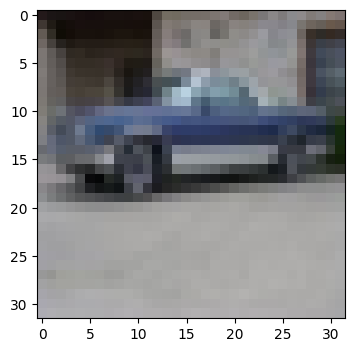

In [12]:
img = data['image_data'][10000]

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.show()

In [13]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [14]:
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, BatchNormalization, Dropout

In [16]:
model = Sequential()

In [17]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [18]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 30, 30, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 14, 14, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 64)       

In [19]:
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

In [20]:
data.shape

(50000, 2)

In [21]:
data.head()

,image_data,label
0,"[[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...",6
1,"[[[154, 177, 187], [126, 137, 136], [105, 104,...",9
2,"[[[255, 255, 255], [253, 253, 253], [253, 253,...",9
3,"[[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...",4
4,"[[[170, 180, 198], [168, 178, 196], [177, 185,...",1


In [22]:
data['image_data'] = data['image_data'] / 255.0

In [23]:
data['image_data'] = data['image_data'].map(lambda x: (np.round(x, 2)))

In [24]:
data.head()

,image_data,label
0,"[[[0.23, 0.24, 0.25], [0.17, 0.18, 0.18], [0.2...",6
1,"[[[0.6, 0.69, 0.73], [0.49, 0.54, 0.53], [0.41...",9
2,"[[[1.0, 1.0, 1.0], [0.99, 0.99, 0.99], [0.99, ...",9
3,"[[[0.11, 0.1, 0.04], [0.15, 0.13, 0.07], [0.15...",4
4,"[[[0.67, 0.71, 0.78], [0.66, 0.7, 0.77], [0.69...",1


In [25]:
images = np.array(data['image_data'].tolist())  # Convert list of 3D arrays to numpy array
labels = np.array(data['label'])  

In [26]:
images.shape

(50000, 32, 32, 3)

In [27]:
labels.shape

(50000,)

In [28]:
valid = data.groupby('label').apply(lambda x: x.sample(1000)).reset_index(drop=True)

In [29]:
valid.sample(frac=1)

,image_data,label
7657,"[[[0.09, 0.05, 0.09], [0.09, 0.06, 0.1], [0.1,...",7
4705,"[[[0.97, 0.99, 0.99], [0.97, 0.98, 0.96], [0.9...",4
1214,"[[[0.33, 0.45, 0.51], [0.33, 0.44, 0.5], [0.34...",1
4601,"[[[0.8, 0.81, 0.62], [0.8, 0.81, 0.62], [0.77,...",4
4233,"[[[0.15, 0.19, 0.07], [0.12, 0.17, 0.04], [0.1...",4
...,...,...
9113,"[[[0.82, 0.95, 0.97], [0.79, 0.94, 0.93], [0.5...",9
3924,"[[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0,...",3
4990,"[[[0.03, 0.18, 0.03], [0.03, 0.16, 0.04], [0.0...",4
2853,"[[[0.17, 0.24, 0.1], [0.22, 0.27, 0.12], [0.24...",2


In [30]:
images_valid = np.array(valid['image_data'].tolist())
labels_valid = np.array(valid['label'])

In [31]:
training = model.fit(images, labels, epochs=50, validation_data=(images_valid, labels_valid))

Epoch 1/50
1563/1563 [==============================] - 11s 5ms/step - loss: 1.9071 - sparse_categorical_accuracy: 0.3334 - val_loss: 1.4371 - val_sparse_categorical_accuracy: 0.4898
Epoch 2/50
1563/1563 [==============================] - 7s 4ms/step - loss: 1.4923 - sparse_categorical_accuracy: 0.4535 - val_loss: 1.3709 - val_sparse_categorical_accuracy: 0.5077
Epoch 3/50
1563/1563 [==============================] - 7s 4ms/step - loss: 1.3776 - sparse_categorical_accuracy: 0.5012 - val_loss: 1.3057 - val_sparse_categorical_accuracy: 0.5332
Epoch 4/50
1563/1563 [==============================] - 6s 4ms/step - loss: 1.2896 - sparse_categorical_accuracy: 0.5336 - val_loss: 1.1425 - val_sparse_categorical_accuracy: 0.5855
Epoch 5/50
1563/1563 [==============================] - 6s 4ms/step - loss: 1.2202 - sparse_categorical_accuracy: 0.5638 - val_loss: 1.0586 - val_sparse_categorical_accuracy: 0.6143
Epoch 6/50
1563/1563 [==============================] - 7s 4ms/step - loss: 1.1582 - spar

In [32]:
import pickle

# Path to the CIFAR-100 train file
file_path = r'.\Dataset\cifar-10-batches-py\test_batch'

# Load the data using pickle with the correct encoding
with open(file_path, 'rb') as f:
    test_dict = pickle.load(f, encoding='latin1')

# The data_dict will contain the images and their corresponding labels
print(test_dict.keys())  # This will show the keys in the dictionary (like 'data', 'labels', etc.)

dict_keys(['batch_label', 'labels', 'data', 'filenames'])


In [33]:
test = pd.DataFrame({
    'image_data': list(test_dict['data']),  # Each row will contain 3072 values for image data
    'label': test_dict['labels']  # Fine-grained labels
})

In [34]:
test.head()

,image_data,label
0,"[158, 159, 165, 166, 160, 156, 162, 159, 158, ...",3
1,"[235, 231, 232, 232, 232, 232, 232, 232, 232, ...",8
2,"[158, 158, 139, 132, 166, 182, 187, 193, 199, ...",8
3,"[155, 167, 176, 190, 177, 166, 168, 166, 170, ...",0
4,"[65, 70, 48, 30, 23, 40, 44, 45, 45, 40, 10, 1...",6


In [35]:
test['image_data'] = test['image_data'].apply(
    lambda x: np.array(x).reshape((3, 32, 32)).transpose(1, 2, 0)
)

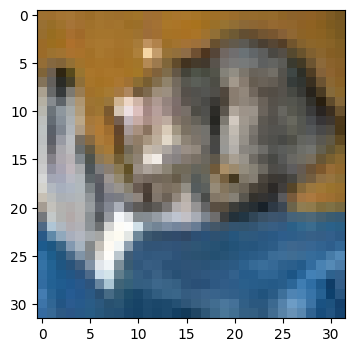

In [36]:
plt.figure(figsize=(4, 4))
plt.imshow(test['image_data'][0])
plt.show()

In [37]:
test.head()

,image_data,label
0,"[[[158, 112, 49], [159, 111, 47], [165, 116, 5...",3
1,"[[[235, 235, 235], [231, 231, 231], [232, 232,...",8
2,"[[[158, 190, 222], [158, 187, 218], [139, 166,...",8
3,"[[[155, 156, 149], [167, 176, 187], [176, 179,...",0
4,"[[[65, 68, 50], [70, 81, 64], [48, 64, 46], [3...",6


In [38]:
test['image_data'] = test['image_data'] / 255.0

In [39]:
test['image_data'] = test['image_data'].map(lambda x: (np.round(x, 2)))

In [40]:
test_images = np.array(test['image_data'].tolist())  # Convert list of 3D arrays to numpy array
test_labels = np.array(test['label'])  

In [41]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 2s 5ms/step - loss: 0.6649 - sparse_categorical_accuracy: 0.7742


[0.6649485230445862, 0.7742000222206116]

In [42]:
test_pred = model.predict(test_images)

In [44]:
test_pred[0]

array([6.2498072e-04, 1.4914843e-04, 1.9323472e-02, 8.4534329e-01,
       1.5444931e-03, 5.1471837e-02, 7.8085594e-02, 7.3968328e-04,
       2.2290496e-03, 4.8834633e-04], dtype=float32)

In [45]:
test_pred = test_pred.argmax(axis=-1)

In [46]:
f1_class = f1_score(test_labels, test_pred,average=None)
print(f1_class)

[0.76116071 0.88165038 0.67020712 0.60257069 0.75600739 0.70908158
 0.77860082 0.82587601 0.86862004 0.88043478]


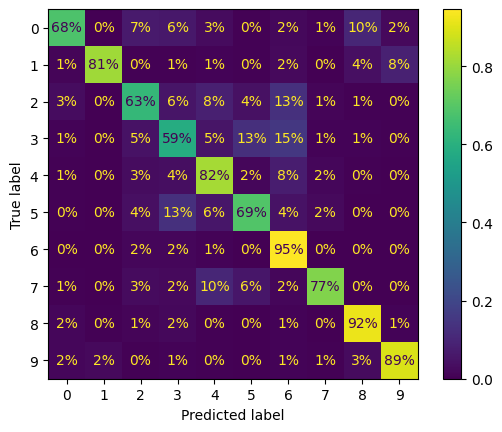

In [47]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_pred, normalize='true', values_format='.0%')

In [48]:
model.save(os.path.join('models','cifer_classifier_CNN2.h5'))